# Figure 7 error bars
## Abby Barlow, The University of Bath
Plots the various figures in Figure 7 for proportion of wildtype-free households, mean number Wolbachia-infected per household and proportion of time the houshold contains Wolbachia infection. Data for the plots is processed in a separate notebook 'propn_hhold_results.ipynb'.


Imports libraries

In [1]:
%matplotlib inline
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib.pyplot as plt

Loads the processed data for the figure. The csv file needs changing for different figures.

In [2]:
# Load the CSV file into a DataFrame
wolb_av_df = pd.read_csv('../single_hhold_release\\wild_free_propn_hhold_1_rel.csv')

# Convert the DataFrame to a dictionary for easier access
ratios_dict = {(eval(row['SexRatio']), row['ReleaseTimeStep']): row['InvProb'] for _, row in wolb_av_df.iterrows()}
ratios_dict

{((3, 10), 75): 0.01,
 ((5, 10), 25): 0.21,
 ((10, 1), 10): 1.0,
 ((10, 10), 10): 1.0,
 ((5, 1), 75): 0.03,
 ((3, 3), 50): 0.02,
 ((5, 10), 75): 0.01,
 ((3, 5), 100): 0.01,
 ((10, 3), 100): 0.02,
 ((1, 1), 50): 0.0,
 ((3, 5), 25): 0.03,
 ((5, 3), 50): 0.06,
 ((3, 3), 10): 0.44,
 ((10, 3), 25): 0.63,
 ((3, 1), 50): 0.03,
 ((5, 5), 100): 0.01,
 ((10, 5), 50): 0.15,
 ((3, 10), 50): 0.0,
 ((10, 1), 100): 0.02,
 ((3, 5), 75): 0.0,
 ((1, 1), 10): 0.02,
 ((10, 3), 75): 0.08,
 ((5, 5), 25): 0.17,
 ((10, 10), 100): 0.01,
 ((5, 3), 10): 0.93,
 ((5, 1), 50): 0.02,
 ((3, 1), 10): 0.33,
 ((10, 1), 25): 0.53,
 ((10, 5), 10): 1.0,
 ((5, 10), 50): 0.02,
 ((3, 10), 10): 0.6,
 ((10, 10), 25): 0.66,
 ((5, 5), 75): 0.02,
 ((10, 1), 75): 0.03,
 ((5, 1), 10): 0.83,
 ((3, 3), 100): 0.0,
 ((10, 10), 75): 0.05,
 ((5, 10), 10): 0.96,
 ((3, 3), 25): 0.02,
 ((1, 1), 100): 0.03,
 ((3, 5), 50): 0.01,
 ((5, 3), 100): 0.02,
 ((10, 3), 50): 0.19,
 ((3, 1), 100): 0.0,
 ((10, 5), 100): 0.02,
 ((1, 1), 25): 0.0,
 ((3, 3)

Plots the figure for the different release time steps and numbers of males and females released on each release event.

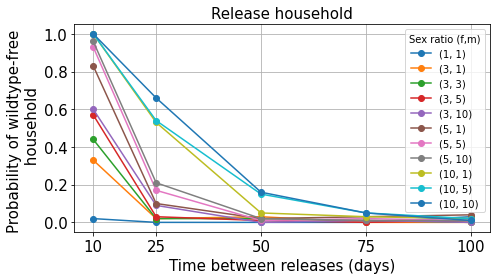

In [3]:
plt.figure(figsize=(7, 4))  # figure size in inches

# sex ratio labels
bar_labels = [(1,1), (3,1), (3,3), (3,5), (3,10), (5,1), (5,5), (5,10), (10,1), (10,5), (10,10)]
# time steps for the x-axis
time_steps = [10, 25, 50, 75, 100]  # or your actual time steps
# colors for the lines
colors =['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11'] #plt.cm.viridis(np.linspace(0, 1, len(bar_labels)))

for idx, label in enumerate(bar_labels):  # loop through each release combination
    yvals = [ratios_dict.get((label, t), np.nan) for t in time_steps]
    plt.plot(time_steps, yvals, marker='o', color=colors[idx], label=str(label))

# titles and legend
plt.xlabel('Time between releases (days)', color='black', fontsize=15)
plt.ylabel('Probability of wildtype-free \n household', color='black', fontsize=15)
plt.title('Release household', color='black', fontsize=15)
plt.xticks(time_steps, color='black', fontsize=15)
plt.yticks(color='black', fontsize=15)
plt.legend(fontsize=10, loc='best', title='Sex ratio (f,m)', title_fontsize=10)
plt.grid()
plt.tight_layout()
#plt.savefig('wolbachia_all_households_size_line.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
wild_av_df = pd.read_csv('../single_hhold_release\\wolb_av_propn_hhold_1_norel.csv')

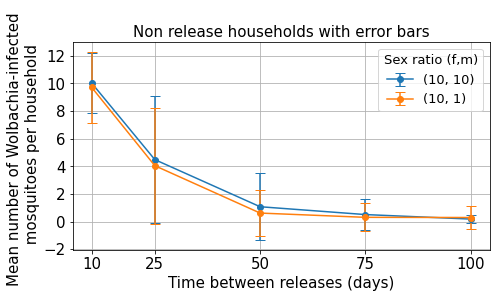

In [17]:
plt.figure(figsize=(7, 4))  # new figure for each sex ratio
bar_labels = [(10,10), (10,1)]
# time steps for the x-axis
time_steps = [10, 25, 50, 75, 100]

# Plot mean and standard deviation error bars instead of quantile intervals
for idx, label in enumerate(bar_labels):
    df_label = wild_av_df[wild_av_df['SexRatio'] == str(label)]
    means = []
    stds = []
    for t in time_steps:
        row = df_label[df_label['ReleaseTimeStep'] == t]
        means.append(row['Mean'].values[0])
        stds.append(row['Std'].values[0])

    plt.errorbar(time_steps, means, yerr=stds, marker='o', color=colors[idx], label=str(label), capsize=5)
plt.xlabel('Time between releases (days)', color='black', fontsize=15)
plt.ylabel('Mean number of Wolbachia-infected \n mosquitoes per household', color='black', fontsize=15)
plt.xticks(time_steps, color='black', fontsize=15)
plt.yticks(color='black', fontsize=15)
plt.legend(fontsize=13, loc='best', title='Sex ratio (f,m)', title_fontsize=13)
plt.title(f'Non release households with error bars', color='black', fontsize=15)
plt.grid()
plt.tight_layout()
#plt.savefig('wolb_av_scaled_time_1norel_CI.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
pers_df = pd.read_csv('../single_hhold_release\\wolb_pers_propn_hhold_1_norel.csv')

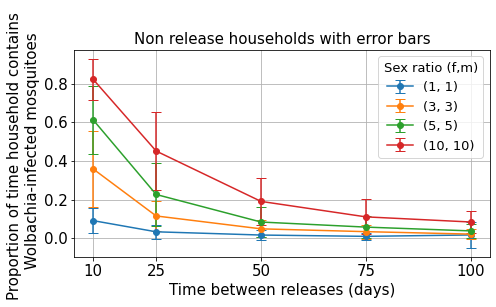

In [16]:
import numpy as np
#import ggplot as gg
#import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))  # new figure for each sex ratio
bar_labels = [(1,1), (3,3), (5,5), (10,10)]
# time steps for the x-axis
time_steps = [10, 25, 50, 75, 100]

# Plot mean and standard deviation error bars instead of quantile intervals
for idx, label in enumerate(bar_labels):
    df_label = pers_df[pers_df['SexRatio'] == str(label)]
    means = []
    stds = []
    for t in time_steps:
        row = df_label[df_label['ReleaseTimeStep'] == t]
        means.append(row['Mean'].values[0])
        stds.append(row['Std'].values[0])

    plt.errorbar(time_steps, means, yerr=stds, marker='o', color=colors[idx], label=str(label), capsize=5)
plt.xlabel('Time between releases (days)', color='black', fontsize=15)
plt.ylabel('Proportion of time household contains \n Wolbachia-infected mosquitoes', color='black', fontsize=15)
plt.xticks(time_steps, color='black', fontsize=15)
plt.yticks(color='black', fontsize=15)
plt.legend(fontsize=13, loc='best', title='Sex ratio (f,m)', title_fontsize=13)
plt.title(f'Non release households with error bars', color='black', fontsize=15)
plt.grid()
plt.tight_layout()
plt.savefig('wolbachia_pers_scaled_time_1norel_CI.pdf', dpi=300, bbox_inches='tight')
plt.show()